Cubic Interpolating Spline

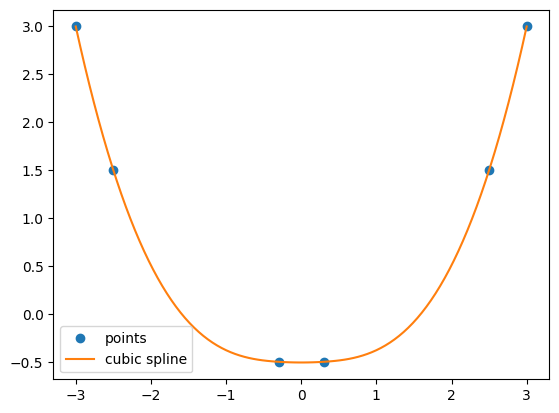

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Example points
xs = np.array([-3, -2.5, -0.3, 0.3, 2.5, 3])
ys = np.array([3, 1.5, -0.5, -0.5, 1.5, 3])

# xs = np.array([-3, -2.3, 0, 2.3, 3])
# ys = np.array([3, 0, -2.5, 0, 3])

# xs = np.array([-3,  0,  3])
# ys = np.array([3, -1, 3])

# Build cubic spline
cs = CubicSpline(xs, ys)

# Plot
x_plot = np.linspace(xs.min(), xs.max(), 100)
plt.plot(xs, ys, 'o', label='points')
plt.plot(x_plot, cs(x_plot), '-', label='cubic spline')
plt.legend()
plt.show()


интерполяционный кубический сплайн

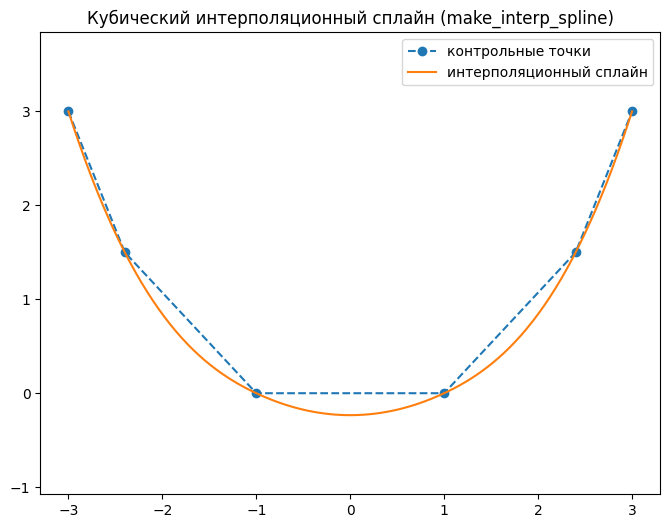

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Контрольные точки (через них должна пройти кривая)
points = np.array([[-3,3], [-2.4,1.5], [-1,0], [1,0], [2.4,1.5], [3,3]])
x = points[:,0]
y = points[:,1]

# Строим кубический интерполяционный сплайн
spl = make_interp_spline(x, y, k=3)

# Новый диапазон x
x_new = np.linspace(x.min(), x.max(), 200)
y_new = spl(x_new)

# Визуализация
plt.figure(figsize=(8,6))
plt.plot(x, y, 'o--', label='контрольные точки')
plt.plot(x_new, y_new, '-', label='интерполяционный сплайн')
plt.legend()
plt.axis('equal')
plt.title("Кубический интерполяционный сплайн (make_interp_spline)")
plt.show()

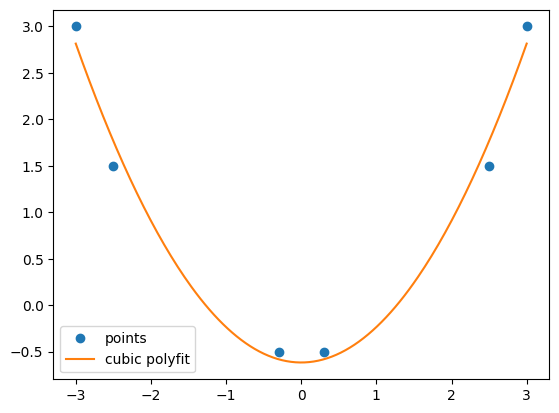

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Example points
xs = np.array([-3, -2.5, -0.3, 0.3, 2.5, 3])
ys = np.array([3, 1.5, -0.5, -0.5, 1.5, 3])

# Fit a cubic polynomial (degree=3)
coeffs = np.polyfit(xs, ys, deg=3)
poly = np.poly1d(coeffs)

# Plot
x_plot = np.linspace(xs.min(), xs.max(), 200)
plt.plot(xs, ys, 'o', label='points')
plt.plot(x_plot, poly(x_plot), '-', label='cubic polyfit')
plt.legend()
plt.show()

2. Parametric Spline in 2D

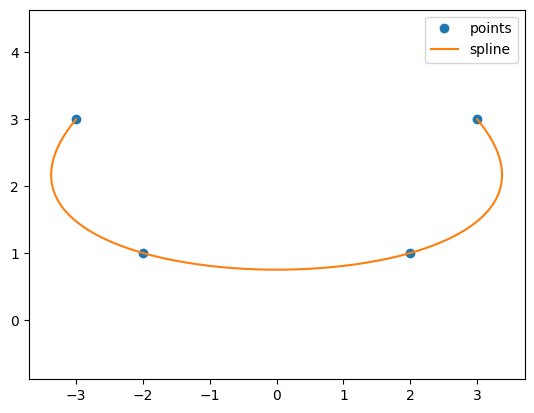

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, BSpline

# Four arbitrary points
points = np.array([[-3,3],[-2,1],[2,1],[3,3]])
t = np.arange(len(points))  # parameter

# Spline for x(t), y(t)
cs_x = CubicSpline(t, points[:,0])
cs_y = CubicSpline(t, points[:,1])

# Evaluate
t_new = np.linspace(t.min(), t.max(), 200)
x_new, y_new = cs_x(t_new), cs_y(t_new)

plt.plot(points[:,0], points[:,1], 'o', label='points')
plt.plot(x_new, y_new, '-', label='spline')
plt.legend()
plt.axis('equal')
plt.show()


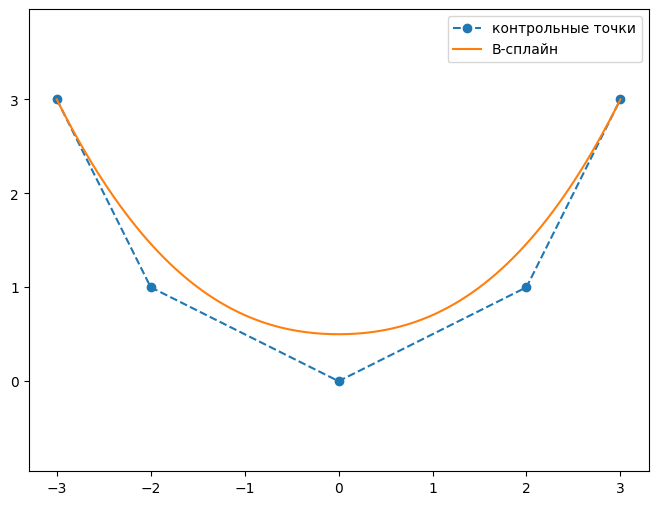

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline

# Контрольные точки
points = np.array([[-3,3],[-2,1],[0,0],[2,1],[3,3]])
points_len = len(points)
x = points[:,0]
y = points[:,1]

# Степень сплайна
k = 3  # кубический

# Количество коэффициентов
n = len(points)

# Узловой вектор: длина должна быть n + k + 1 = 5 + 3 + 1 = 9
# Используем "clamped" (открытый равномерный) узловой вектор
t = np.array([0, 0, 0, 0, 1, 2, 2, 2, 2], dtype=float)

spl = BSpline(t, points, k)

# Параметр u
u = np.linspace(t[k], t[n], 200)
curve = spl(u)

# Визуализация
plt.figure(figsize=(8,6))
plt.plot(points[:,0], points[:,1], 'o--', label='контрольные точки')
plt.plot(curve[:,0], curve[:,1], '-', label='B‑сплайн')
plt.legend()
plt.axis('equal')
plt.show()